In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
# Load the dataset
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'
df = pd.read_csv(url)

# Select categorical and numerical columns (excluding the target)
categorical = df.select_dtypes(include=['object', 'str']).columns.tolist()
numerical = df.select_dtypes(exclude=['object', 'str']).columns.tolist()

if 'converted' in categorical:
    categorical.remove('converted')
if 'converted' in numerical:
    numerical.remove('converted')

# Fill missing values
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

# Split the data with random_state=1
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

y_full_train = df_full_train['converted'].values
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

del df_full_train['converted']
del df_train['converted']
del df_val['converted']
del df_test['converted']

# Q1

In [3]:
numerical_features = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']
auc_scores = {}

for f in numerical_features:
    # Compute AUC
    auc = roc_auc_score(y_train, df_train[f])

    # Invert the variable if AUC is < 0.5
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[f])

    auc_scores[f] = auc
    print(f"{f:<25}: {auc:.4f}")

best_feature = max(auc_scores, key=auc_scores.get)
print(f"\nFeature with highest AUC: {best_feature}")

lead_score               : 0.7882
number_of_courses_viewed : 0.7230
interaction_count        : 0.7649
annual_income            : 0.6082

Feature with highest AUC: lead_score


# Q2

In [4]:
# One-hot encoding
dv = DictVectorizer(sparse=False)
train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

# Train the model
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# Predict probabilities and calculate AUC
y_pred = model.predict_proba(X_val)[:, 1]
auc_val = roc_auc_score(y_val, y_pred)

print(f"Validation AUC: {round(auc_val, 3)}")

Validation AUC: 0.732


In [5]:
thresholds = np.linspace(0, 1, 101)
scores = []

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    # Handle division by zero
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    scores.append((t, precision, recall, f1))

df_scores = pd.DataFrame(scores, columns=['threshold', 'precision', 'recall', 'f1'])

# Q3

Intersection threshold (Q3): 0.63


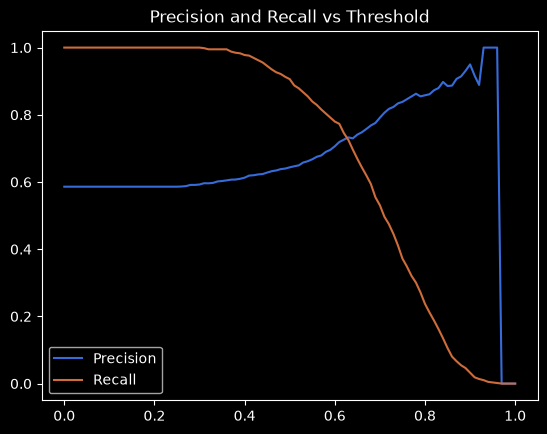

In [6]:
df_scores['diff'] = abs(df_scores['precision'] - df_scores['recall'])
valid_intersect = df_scores[(df_scores['precision'] > 0) & (df_scores['recall'] > 0)]
best_intersect_t = valid_intersect.loc[valid_intersect['diff'].idxmin()]['threshold']
print(f"Intersection threshold (Q3): {best_intersect_t}")

# Plotting Precision and Recall
plt.plot(df_scores.threshold, df_scores.precision, label='Precision')
plt.plot(df_scores.threshold, df_scores.recall, label='Recall')
plt.legend()
plt.title("Precision and Recall vs Threshold")
plt.show()

# Q4

In [7]:
best_f1_t = df_scores.loc[df_scores['f1'].idxmax()]['threshold']
print(f"Maximal F1 threshold (Q4): {best_f1_t}")

Maximal F1 threshold (Q4): 0.41000000000000003


In [8]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    return dv, model

def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

# Q5

In [9]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
fold_scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    # Slice the features
    df_train_fold = df_full_train.iloc[train_idx]
    df_val_fold = df_full_train.iloc[val_idx]

    # Slice the target array directly using the indices
    y_train_fold = y_full_train[train_idx]
    y_val_fold = y_full_train[val_idx]

    dv, model = train(df_train_fold, y_train_fold, C=1.0)
    y_pred_fold = predict(df_val_fold, dv, model)

    auc = roc_auc_score(y_val_fold, y_pred_fold)
    fold_scores.append(auc)

std_dev = np.std(fold_scores)
print(f"Standard deviation across folds: {round(std_dev, 3)}")

Standard deviation across folds: 0.007


# Q6

In [10]:
c_values = [0.000001, 0.001, 1]

for C in c_values:
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)
    fold_scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        # Slice the features
        df_train_fold = df_full_train.iloc[train_idx]
        df_val_fold = df_full_train.iloc[val_idx]

        # Slice the target array directly using the indices
        y_train_fold = y_full_train[train_idx]
        y_val_fold = y_full_train[val_idx]

        dv, model = train(df_train_fold, y_train_fold, C=C)
        y_pred_fold = predict(df_val_fold, dv, model)

        auc = roc_auc_score(y_val_fold, y_pred_fold)
        fold_scores.append(auc)

    mean_auc = np.mean(fold_scores)
    std_auc = np.std(fold_scores)

    print(f"C = {C:<8} | Mean AUC = {round(mean_auc, 3)} | Std = {round(std_auc, 3)}")

C = 1e-06    | Mean AUC = 0.617 | Std = 0.019
C = 0.001    | Mean AUC = 0.749 | Std = 0.01
C = 1        | Mean AUC = 0.732 | Std = 0.007
